In [2]:
#Loading the Library
import pandas as pd

In [4]:
#import the csv
nike_sales = pd.read_csv(r'C:\Users\HP\Desktop\Nike_Sales_Uncleaned.csv')

In [5]:
#Go Through the CSV file and print the contents
nike_sales

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,4495,Kids,Basketball,Kyrie Flytrap,XL,3.0,NaN,NaN,0.0,2025-05-14,Online,Pune,2.97
2496,4496,Men,Basketball,Kyrie Flytrap,L,-1.0,NaN,NaN,0.0,NaN,Online,Hyd,-487.36
2497,4497,Men,Soccer,Tiempo Legend,7,NaN,6647.60,0.52,0.0,02-07-2025,Retail,Bangalore,-918.14
2498,4498,Women,Training,ZoomX Invincible,NaN,4.0,5358.70,NaN,0.0,11-12-2024,Online,Mumbai,3352.29


In [7]:
# 1. Check for missing values in the dataset
nike_sales.isnull().sum()
# 2. Basic Cleaning
nike_sales["Units_Sold"] = nike_sales["Units_Sold"].fillna(0)
nike_sales["MRP"] = nike_sales["MRP"].fillna(nike_sales["MRP"].median())
nike_sales["Discount_Applied"] = nike_sales["Discount_Applied"].fillna(0)

#3. Drop rows with missing values in the "Order_Date" column
nike_sales = nike_sales.dropna(subset=["Order_Date"])

# 4 Checcking agai
print(nike_sales.isnull().sum())
print(nike_sales.shape)

Order_ID              0
Gender_Category       0
Product_Line          0
Product_Name          0
Size                393
Units_Sold            0
MRP                   0
Discount_Applied      0
Revenue               0
Order_Date            0
Sales_Channel         0
Region                0
Profit                0
dtype: int64
(1884, 13)


In [10]:
# Basic Data Analysis
print(nike_sales.groupby("Gender_Category")["Revenue"].sum().sort_values(ascending=False))
print(nike_sales.groupby("Sales_Channel")["Revenue"].sum())
print(nike_sales.groupby("Product_Name")["Revenue"].sum().sort_values(ascending=False))
print(nike_sales.groupby("Product_Name")["Revenue"].sum().sort_values(ascending=False).head(5))

Gender_Category
Men      221981.23
Women    198269.22
Kids     126535.71
Name: Revenue, dtype: float64
Sales_Channel
Online    302639.18
Retail    244146.98
Name: Revenue, dtype: float64
Product_Name
LeBron 20             63676.17
Flex Trainer          54550.17
Zoom Freak            50856.94
ZoomX Invincible      36765.77
Premier III           35194.08
Air Force 1           34041.68
Phantom GT            33222.99
Air Jordan            32226.62
Metcon 7              31746.19
SuperRep Go           28798.66
Mercurial Superfly    26389.34
Dunk Low              23598.52
Waffle One            21070.02
Tiempo Legend         20121.64
Blazer Mid            17463.90
Air Zoom              10646.53
React Infinity         9943.73
Free RN                8048.90
Kyrie Flytrap          7451.09
Pegasus Turbo           973.22
Name: Revenue, dtype: float64
Product_Name
LeBron 20           63676.17
Flex Trainer        54550.17
Zoom Freak          50856.94
ZoomX Invincible    36765.77
Premier III         3

In [11]:
# Fill missing values in the "Siza" column with Unknown
nike_sales["Size"] = nike_sales["Size"].fillna("Unknown")

#Check again
print(nike_sales.isnull().sum())

Order_ID            0
Gender_Category     0
Product_Line        0
Product_Name        0
Size                0
Units_Sold          0
MRP                 0
Discount_Applied    0
Revenue             0
Order_Date          0
Sales_Channel       0
Region              0
Profit              0
dtype: int64


In [14]:
# Run This for Avg, Total, Top 5
#1 Average revenue by gender + Channel
print(nike_sales.groupby(["Gender_Category", "Sales_Channel"])["Revenue"].mean().round(2))
#2 Total Profit by Product_Line
print(nike_sales.groupby("Product_Line")["Profit"].sum().sort_values(ascending=False))
#3 Top 5 Products by Revenue
print(nike_sales.groupby("Product_Name")["Revenue"].sum().sort_values(ascending = False).head(5))
#4 New Column Creation
nike_sales["Revenue_in Thousands"] = nike_sales["Revenue"]/1000

Gender_Category  Sales_Channel
Kids             Online           144.72
                 Retail           254.46
Men              Online           404.03
                 Retail           302.92
Women            Online           418.75
                 Retail           225.10
Name: Revenue, dtype: float64
Product_Line
Lifestyle     540819.80
Training      516810.12
Soccer        510433.88
Basketball    509993.89
Running       485481.48
Name: Profit, dtype: float64
Product_Name
LeBron 20           63676.17
Flex Trainer        54550.17
Zoom Freak          50856.94
ZoomX Invincible    36765.77
Premier III         35194.08
Name: Revenue, dtype: float64


In [15]:
#! Filtering High Revenue Transactions
high_revenue_transactions = nike_sales[nike_sales["Revenue"] > 500]
#2 Value Counts
print(nike_sales["Gender_Category"].value_counts())
print(nike_sales["Sales_Channel"].value_counts())
#3 Simple Pivot Table
pivot = nike_sales.pivot_table(
    values="Revenue",
    index="Gender_Category",
    columns="Sales_Channel",
    aggfunc="sum",
)
print(pivot)

# 4 Save the cleaned dataset to a new CSV file
nike_sales.to_csv("Nike_Cleaned_Cleaned_Pythonn.csv", index=False)
print("File saved successfully")

Gender_Category
Kids     637
Men      626
Women    621
Name: count, dtype: int64
Sales_Channel
Online    946
Retail    938
Name: count, dtype: int64
Sales_Channel       Online    Retail
Gender_Category                     
Kids              46888.19  79647.52
Men              129288.43  92692.80
Women            126462.56  71806.66
File saved successfully


In [16]:
import os
file_path = os.path.abspath("Nike_Cleaned_Cleaned_Pythonn.csv")
print(file_path)

c:\Users\HP\AppData\Local\Programs\Microsoft VS Code\Nike_Cleaned_Cleaned_Pythonn.csv


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

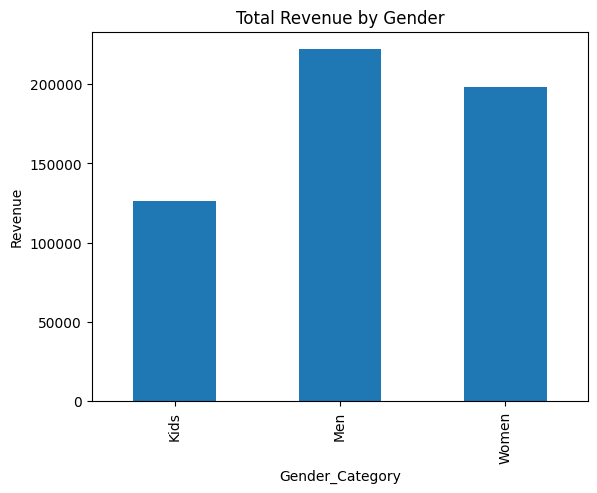

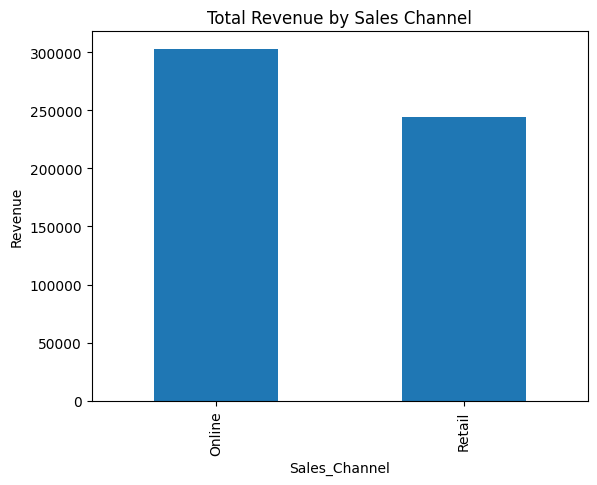

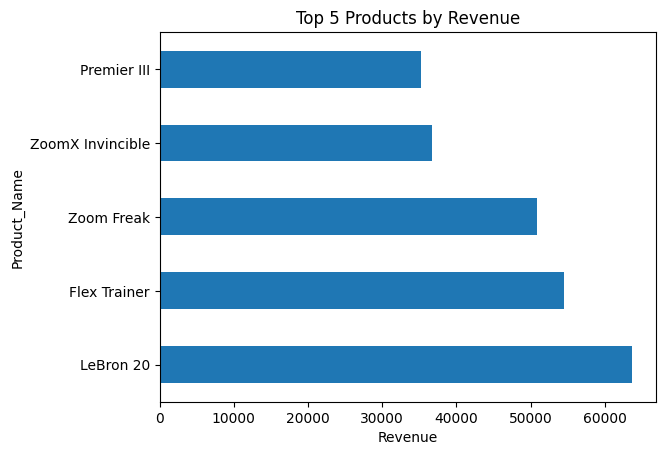

In [19]:
#1 Revenue by Gender
gender_rev = nike_sales.groupby("Gender_Category")["Revenue"].sum()
gender_rev.plot(kind= "bar")
plt.title("Total Revenue by Gender")
plt.ylabel("Revenue")
plt.show()

#2. Revenue by sales
gender_rev = nike_sales.groupby("Sales_Channel")["Revenue"].sum()
gender_rev.plot(kind= "bar")
plt.title("Total Revenue by Sales Channel")
plt.ylabel("Revenue")
plt.show()

#3.Top 5 Products
# 3. Top 5 Products
top5 = nike_sales.groupby("Product_Name")["Revenue"].sum().sort_values(ascending=False).head(5)
top5.plot(kind="barh")
plt.title("Top 5 Products by Revenue")
plt.xlabel("Revenue")
plt.show()

In [24]:
# Standardize Region names
nike_sales["Region"] = nike_sales["Region"].str.strip().str.title()

# Fix specific inconsistencies
nike_sales["Region"] = nike_sales["Region"].replace({
    "Bengaluru": "Bangalore",
    "Hyd": "Hyderabad",
    "Hyderbad": "Hyderabad"  # already correct after title()
})

# Check unique values after cleaning
print(nike_sales["Region"].unique())
print(nike_sales["Region"].value_counts())

<StringArray>
['Bangalore', 'Hyderabad', 'Pune', 'Delhi', 'Kolkata', 'Mumbai']
Length: 6, dtype: str
Region
Bangalore    324
Delhi        322
Mumbai       322
Kolkata      317
Hyderabad    309
Pune         290
Name: count, dtype: int64


In [25]:
nike_sales.to_csv("Nike_Cleaned_Cleaned_Python.csv", index=False)
print("File saved successfully")

File saved successfully


In [ ]:
file_path = os.path.abspath("Nike_Cleaned_Cleaned_Python.csv")
print(file_path)

c:\Users\HP\AppData\Local\Programs\Microsoft VS Code\Nike_Cleaned_Cleaned_Pythonn.csv


In [26]:
# === Final Summary ===

print("===== NIKE SALES ANALYSIS SUMMARY =====")
print("\nTotal Revenue:", round(nike_sales["Revenue"].sum(), 2))
print("Total Profit:", round(nike_sales["Profit"].sum(), 2))
print("Total Transactions:", nike_sales.shape[0])

print("\n--- Revenue by Gender ---")
print(nike_sales.groupby("Gender_Category")["Revenue"].sum().sort_values(ascending=False))

print("\n--- Revenue by Channel ---")
print(nike_sales.groupby("Sales_Channel")["Revenue"].sum().sort_values(ascending=False))

print("\n--- Top 5 Products ---")
print(nike_sales.groupby("Product_Name")["Revenue"].sum().sort_values(ascending=False).head(5))

print("\n--- Average Revenue by Gender + Channel ---")
print(nike_sales.groupby(["Gender_Category", "Sales_Channel"])["Revenue"].mean().round(2))

===== NIKE SALES ANALYSIS SUMMARY =====

Total Revenue: 546786.16
Total Profit: 2563539.17
Total Transactions: 1884

--- Revenue by Gender ---
Gender_Category
Men      221981.23
Women    198269.22
Kids     126535.71
Name: Revenue, dtype: float64

--- Revenue by Channel ---
Sales_Channel
Online    302639.18
Retail    244146.98
Name: Revenue, dtype: float64

--- Top 5 Products ---
Product_Name
LeBron 20           63676.17
Flex Trainer        54550.17
Zoom Freak          50856.94
ZoomX Invincible    36765.77
Premier III         35194.08
Name: Revenue, dtype: float64

--- Average Revenue by Gender + Channel ---
Gender_Category  Sales_Channel
Kids             Online           144.72
                 Retail           254.46
Men              Online           404.03
                 Retail           302.92
Women            Online           418.75
                 Retail           225.10
Name: Revenue, dtype: float64


# Insights
- Men generated the highest total revenue, followed by Women and then Kids.
- LeBron 20 is the top-selling product by revenue. It generated approximately 15% more revenue than the second-highest product, Flex Trainer.
- Women showed a strong preference for the Online channel compared to Retail. The gap between Online and Retail revenue is significantly larger for Women than for Men.